In [7]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from pymc_prop import sample_pro

FIGSIZE = (6.5, 4.0)
COLOR_DATA = "0.6"
COLOR_PRO = "#bca0ff"

SEEDS = [0, 1, 2, 3, 4]
N_PARTICLES = 40
N_STEPS = 1000
STEP_SIZE = 8e-4
BURN_IN = 0


In [8]:
N = 800
sigma = 0.7
component_means = np.array([-1.5, 2.25])
component_weights = np.array([0.4, 0.6])
SEED_DATA = 2026

rng = np.random.default_rng(SEED_DATA)
components = rng.choice(len(component_means), size=N, p=component_weights)
y = rng.normal(loc=component_means[components], scale=sigma)
xlim = (component_means.min() - 3 * sigma, component_means.max() + 3 * sigma)

with pm.Model() as model:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)


In [9]:
def mean_pairwise_distance(particles):
    d = np.linalg.norm(particles[:, None, :] - particles[None, :, :], axis=-1)
    iu = np.triu_indices(len(particles), k=1)
    return d[iu].mean()


def run_case(init, seed, jitter=0.1):
    result = sample_pro(
        model=model,
        init=init,
        jitter=jitter,
        n_particles=N_PARTICLES,
        n_steps=N_STEPS,
        burn_in=BURN_IN,
        thinning=1,
        step_size=STEP_SIZE,
        learning_rate=1.0,
        random_seed=seed,
    )
    traj = result.particles
    return {
        "init": init,
        "seed": seed,
        "traj": traj,
        "t0_spread": mean_pairwise_distance(traj[0]),
        "final_spread": mean_pairwise_distance(traj[-1]),
    }

records = []
for seed in SEEDS:
    records.append(run_case("jitter", seed))
    records.append(run_case("prior", seed))

summary = pd.DataFrame(records)[["init", "seed", "t0_spread", "final_spread"]]
summary


,init,seed,t0_spread,final_spread
0,jitter,0,1.024793,3.734511
1,prior,0,2.257185,1.921063
2,jitter,1,1.163531,2.286556
3,prior,1,3.018079,2.285833
4,jitter,2,1.199040,2.196997
5,prior,2,2.398725,1.904383
6,jitter,3,1.485569,1.871989
7,prior,3,3.152272,2.262157
8,jitter,4,1.384735,1.900577
9,prior,4,2.979536,1.982215


In [10]:
def finals_for(init):
    return np.concatenate([r["traj"][-1] for r in records if r["init"] == init], axis=0)


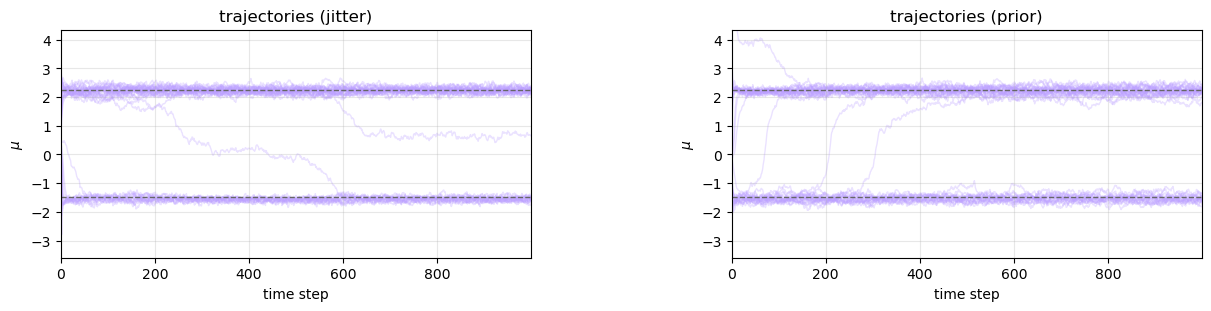

In [11]:
outlier_margin = 2.0

fig, axes = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={"wspace": 0.25}, layout="constrained")
for ax, init in zip(axes, ["jitter", "prior"]):
    rep = next(r for r in records if r["init"] == init and r["seed"] == 0)
    traj = rep["traj"]
    steps = np.arange(traj.shape[0])
    for j in range(traj.shape[1]):
        series = traj[:, j, 0]
        outside = np.max(np.abs(series)) > max(abs(xlim[0]), abs(xlim[1])) + outlier_margin
        ax.plot(
            steps,
            series,
            color="0.45" if outside else COLOR_PRO,
            alpha=0.35 if outside else 0.3,
            lw=0.8 if outside else 1.0,
            zorder=0 if outside else 1,
        )
    for mu in component_means:
        ax.axhline(mu, **dict(color="0.15", linestyle="--", linewidth=1.5, alpha=0.95))
    ax.set(
        title=f"trajectories ({init})",
        xlabel="time step",
        ylabel=r"$\mu$",
        xlim=(0, steps[-1]),
        ylim=xlim,
    )
    ax.grid(alpha=0.3)
plt.show()


/tmp/ipykernel_665938/3945744649.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


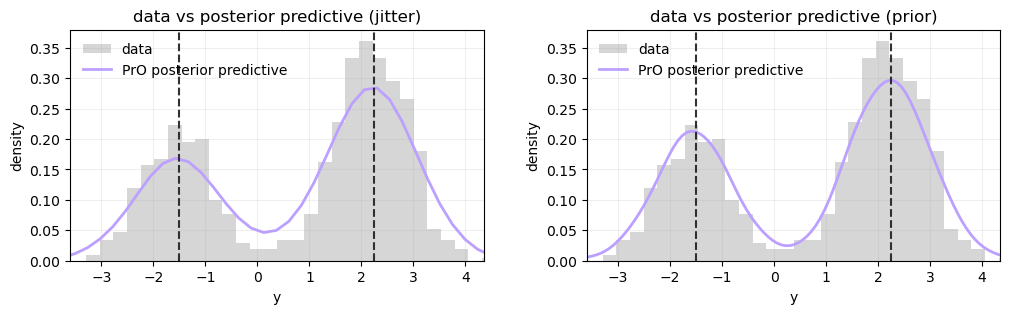

In [16]:
rng_pp = np.random.default_rng(SEED_DATA + 1)
n_rep = max(1, N // N_PARTICLES)

fig, axes = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={"wspace": 0.25})
for ax, init in zip(axes, ["jitter", "prior"]):
    final_particles = finals_for(init)[:, 0]
    y_pp = rng_pp.normal(
        loc=np.repeat(final_particles, n_rep),
        scale=sigma,
    )
    ax.hist(y, bins=30, density=True, alpha=0.4, color=COLOR_DATA, label="data")
    sns.kdeplot(
        y_pp,
        ax=ax,
        color=COLOR_PRO,
        linewidth=2,
        bw_adjust=0.7,
        label="PrO posterior predictive",
    )
    for mu in component_means:
        ax.axvline(mu, **dict(color="0.15", linestyle="--", linewidth=1.5, alpha=0.95))
    ax.set(
        title=f"data vs posterior predictive ({init})",
        xlabel="y",
        ylabel="density",
        xlim=xlim,
    )
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
